# 06 · Clustering
## NHANES 2017–March 2020 Women's CKM Phenotyping Project

---

**Author:** Alexandra Velez, OB-GYN (Colombia) | Data Science
**Input:** `data/processed/clustering_ready.csv` — 1,358 women, 6 scaled
biomarker features
**Output:** `data/processed/cluster_assignments.csv` — cluster labels for
characterization in notebook 07
**Last updated:** 2026

---

### A revision, not the original plan

The first version of this notebook clustered on ten features: six CKM
biomarkers plus four reproductive variables, including APO_Score — the
same variable that encodes GDM and macrosomia history. Notebook 07 then
tested whether the resulting clusters were "enriched" for GDM. That test
was circular: APO_Score helped build the clusters, so finding it back out
again wasn't independent evidence of anything. Notebook 05 was rewritten
to fix this — clustering now runs on the six CKM biomarkers only
(HbA1c, BMI, Mean_SBP, eGFR, HDL, Glucose), with Age_Menarche, Parity,
Pregnancy_Loss, and APO_Score carried forward as descriptive variables,
untouched by the clustering algorithm. This notebook is the corresponding
rewrite. The original 10-feature clustering results are preserved in the
project's git history rather than deleted — the leakage and the fix are
both part of this project's record, not something to paper over.

### Purpose of this notebook

This notebook performs unsupervised phenotyping of the preprocessed CKM
biomarker matrix using k-means clustering. The goal is to identify distinct
cardiometabolic risk profiles among reproductive-age women aged 20–44,
using biomarkers alone — with no information about pregnancy history built
into the clustering itself. Whether those profiles line up with GDM history
is a question for notebook 07 to test, not something baked into this one.

The clustering pipeline is designed for rigor and reproducibility:

1. **K-means across k=2–8** — systematic evaluation of candidate solutions
2. **K selection** — four complementary signals: elbow method, silhouette
   score, Calinski-Harabasz index, and gap statistic
3. **Bootstrap stability analysis** — confirm the selected solution is
   reproducible under data perturbation
4. **Sensitivity analyses** — two independent checks on the primary
   cluster structure:
   - Hierarchical clustering (Ward linkage)
   - StandardScaler vs RobustScaler

### Central clinical question

> Among reproductive-age women aged 20–44, do those with adverse pregnancy
> outcomes — particularly gestational diabetes — already show distinct early
> cardiometabolic biomarker profiles compared to women without APOs?

Clustering on biomarkers alone is the analytical tool that makes it possible
to ask this question honestly. Whether the resulting clusters actually
answer it is notebook 07's job.

---

### A note on unsupervised learning and clinical validity

K-means will always find k clusters — the algorithm cannot return "no
meaningful structure exists." The burden of proof therefore falls on
validation: do the clusters replicate under different methods? Are they
stable under data perturbation? Do they map onto clinically recognizable
phenotypes? This notebook addresses the first two questions. Notebook 07
addresses the third.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import (silhouette_score,
                             calinski_harabasz_score,
                             adjusted_rand_score)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import warnings

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
INPUT_PATH     = Path('../data/processed/clustering_ready.csv')
RAW_PATH       = Path('../data/processed/ckm_features.csv')
OUTPUT_PATH    = Path('../data/processed/cluster_assignments.csv')
FIG_DIR        = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)
PRE_SCALE_PATH = Path('../data/processed/clustering_prescale.csv')

# ── Clustering features — 6 CKM biomarkers only (notebook 05) ──────────────
# Age_Menarche, Parity, Pregnancy_Loss, and APO_Score are carried forward as
# descriptive variables but are NOT used to build the clusters — see the
# note at the top of this notebook on why that changed.
CLUSTERING_FEATURES = [
    'HbA1c',
    'BMI',
    'Mean_SBP',
    'eGFR',
    'HDL',
    'Glucose',
]

# ── K-means hyperparameters ────────────────────────────────────────────────
K_RANGE      = range(2, 9)   # k=2 through k=8
N_INIT       = 50            # initializations per k
MAX_ITER     = 500           # maximum iterations per run
RANDOM_STATE = 42            # reproducibility

# ── Plot style ─────────────────────────────────────────────────────────────
COLORS = {
    'no_apo':     '#0072B2',
    'macs_only':  '#56B4E9',
    'gdm_only':   '#E69F00',
    'gdm_macs':   '#D55E00',
    'never_preg': '#999999',
    'highlight':  '#CC79A7',
}

# Cluster colors — enough for k=8
CLUSTER_COLORS = [
    '#0072B2', '#E69F00', '#009E73', '#D55E00',
    '#CC79A7', '#56B4E9', '#F0E442', '#999999'
]

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Setup complete.')
print(f'  Input:        {INPUT_PATH}')
print(f'  Output:       {OUTPUT_PATH}')
print(f'  Figures:      {FIG_DIR}')
print(f'  K range:      k={min(K_RANGE)}–{max(K_RANGE)}')
print(f'  n_init:       {N_INIT}')
print(f'  random_state: {RANDOM_STATE}')
print(f'\nClustering features ({len(CLUSTERING_FEATURES)}):')
for f in CLUSTERING_FEATURES:
    print(f'  {f}')

Setup complete.
  Input:        ../data/processed/clustering_ready.csv
  Output:       ../data/processed/cluster_assignments.csv
  Figures:      ../figures
  K range:      k=2–8
  n_init:       50
  random_state: 42

Clustering features (6):
  HbA1c
  BMI
  Mean_SBP
  eGFR
  HDL
  Glucose


---
## Section 2 · Load & Validate

In [2]:
# ── Load clustering-ready matrix ───────────────────────────────────────────
df = pd.read_csv(INPUT_PATH, index_col='SEQN')

assert df.shape == (1358, 27), \
    f'Unexpected shape {df.shape} — expected (1358, 27)'
assert df.index.name == 'SEQN', \
    'SEQN is not the index'
assert all(f in df.columns for f in CLUSTERING_FEATURES), \
    'Some clustering features missing from input file'
assert df[CLUSTERING_FEATURES].isna().sum().sum() == 0, \
    'NaN present in clustering features — preprocessing incomplete'

print(f'✓ Clustering matrix loaded: {df.shape}')
print(f'  Index: SEQN')
print(f'  Clustering features: {len(CLUSTERING_FEATURES)} (all complete)')
print(f'  Descriptive variables: {df.shape[1] - len(CLUSTERING_FEATURES)}')

# ── Extract feature matrix ─────────────────────────────────────────────────
X = df[CLUSTERING_FEATURES].values

print(f'\n✓ Feature matrix extracted: {X.shape}')
print(f'  dtype: {X.dtype}')
print(f'  NaN:   {np.isnan(X).sum()}')

# ── APO distribution in clustering sample (descriptive only) ──────────────
# APO_Score is carried forward for notebook 07 — it played no role in
# building the feature matrix above.
print(f'\nAPO distribution in clustering sample:')
print(f'  {"Group":<25} {"N":>6} {"% of sample":>12}')
print(f'  {"─"*25} {"─"*6} {"─"*12}')

never_preg_mask = df['Ever_Pregnant'] == 0
ever_preg_mask  = df['Ever_Pregnant'] == 1

n_never = never_preg_mask.sum()
print(f'  {"Never pregnant":<25} {n_never:>6,} '
      f'{n_never/len(df)*100:>11.1f}%')

apo_map = {
    0.0: 'No APOs',
    1.0: 'Macrosomia only',
    2.0: 'GDM only',
    3.0: 'GDM + Macrosomia',
}
n_known = n_never
for score, label in apo_map.items():
    n = (ever_preg_mask & (df['APO_Score'] == score)).sum()
    n_known += n
    print(f'  {label:<25} {n:>6,} {n/len(df)*100:>11.1f}%')

n_unknown = len(df) - n_known
print(f'  {"Unknown APO status":<25} {n_unknown:>6,} '
      f'{n_unknown/len(df)*100:>11.1f}%')

print(f'  {"─"*25} {"─"*6} {"─"*12}')
print(f'  {"Total":<25} {len(df):>6,} {"100.0%":>12}')

df_pre = pd.read_csv(PRE_SCALE_PATH, index_col='SEQN')
print(f'\n✓ Pre-scale matrix loaded: {df_pre.shape}')

✓ Clustering matrix loaded: (1358, 27)
  Index: SEQN
  Clustering features: 6 (all complete)
  Descriptive variables: 21

✓ Feature matrix extracted: (1358, 6)
  dtype: float64
  NaN:   0

APO distribution in clustering sample:
  Group                          N  % of sample
  ───────────────────────── ────── ────────────
  Never pregnant               391        28.8%
  No APOs                      680        50.1%
  Macrosomia only               97         7.1%
  GDM only                      92         6.8%
  GDM + Macrosomia              25         1.8%
  Unknown APO status            73         5.4%
  ───────────────────────── ────── ────────────
  Total                      1,358       100.0%

✓ Pre-scale matrix loaded: (1603, 59)


---
## Section 3 · K-means Across k=2–8

K-means is run for each candidate k with 50 random initializations
(n_init=50) to avoid local minima — the best solution across all
initializations is retained for each k. Three evaluation metrics are
computed for each solution: inertia (within-cluster sum of squares),
silhouette score, and Calinski-Harabasz index. These form the basis
for k selection in Section 4.

In [3]:
# ── K-means across k=2–8 ──────────────────────────────────────────────────
results = {
    'k':           [],
    'inertia':     [],
    'silhouette':  [],
    'calinski':    [],
    'labels':      {},
    'models':      {},
}

print('Running k-means...\n')
print(f'  {"k":>3}  {"Inertia":>10}  {"Silhouette":>12}  {"Calinski-H":>12}')
print(f'  {"─"*3}  {"─"*10}  {"─"*12}  {"─"*12}')

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        n_init=N_INIT,
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE
    )
    labels = km.fit_predict(X)

    inertia   = km.inertia_
    sil       = silhouette_score(X, labels)
    cal       = calinski_harabasz_score(X, labels)

    results['k'].append(k)
    results['inertia'].append(inertia)
    results['silhouette'].append(sil)
    results['calinski'].append(cal)
    results['labels'][k]  = labels
    results['models'][k]  = km

    print(f'  {k:>3}  {inertia:>10.1f}  {sil:>12.4f}  {cal:>12.2f}')

print(f'\n✓ K-means complete — k={min(K_RANGE)}–{max(K_RANGE)} evaluated')
print(f'  Best silhouette: '
      f'k={results["k"][np.argmax(results["silhouette"])]} '
      f'({max(results["silhouette"]):.4f})')
print(f'  Best Calinski-H: '
      f'k={results["k"][np.argmax(results["calinski"])]} '
      f'({max(results["calinski"]):.2f})')

Running k-means...

    k     Inertia    Silhouette    Calinski-H
  ───  ──────────  ────────────  ────────────
    2      6896.3        0.8305       1061.67


    3      5512.8        0.2793        833.59


    4      4751.1        0.2537        716.70


    5      4265.3        0.1717        636.83


    6      3857.8        0.1650        591.42


    7      3622.5        0.1406        539.11


    8      3409.9        0.1473        502.56

✓ K-means complete — k=2–8 evaluated
  Best silhouette: k=2 (0.8305)
  Best Calinski-H: k=2 (1061.67)


In [4]:
# ── Inspect k=2 solution ───────────────────────────────────────────────────
labels_k2 = results['labels'][2]

print('=== K=2 Solution Inspection ===\n')

for cluster in [0, 1]:
    mask = labels_k2 == cluster
    n    = mask.sum()

    # APO composition
    never = (df.loc[mask, 'Ever_Pregnant'] == 0).sum()
    ever  = (df.loc[mask, 'Ever_Pregnant'] == 1).sum()

    print(f'Cluster {cluster} (n={n:,}):')
    print(f'  Never pregnant:  {never:>4} ({never/n*100:.1f}%)')
    print(f'  Ever pregnant:   {ever:>4} ({ever/n*100:.1f}%)')

    # Mean scaled feature values
    print(f'  Mean scaled feature values:')
    for feat in CLUSTERING_FEATURES:
        mean_val = df.loc[mask, feat].mean()
        print(f'    {feat:<20} {mean_val:>7.3f}')
    print()

=== K=2 Solution Inspection ===

Cluster 0 (n=1,338):
  Never pregnant:   386 (28.8%)
  Ever pregnant:    951 (71.1%)
  Mean scaled feature values:
    HbA1c                  0.115
    BMI                    0.125
    Mean_SBP               0.123
    eGFR                  -0.178
    HDL                    0.117
    Glucose                0.098

Cluster 1 (n=20):
  Never pregnant:     5 (25.0%)
  Ever pregnant:     15 (75.0%)
  Mean scaled feature values:
    HbA1c                 11.137
    BMI                    0.668
    Mean_SBP               0.414
    eGFR                   0.091
    HDL                   -0.343
    Glucose               12.421



### K=2 solution — a methodological finding

All three evaluation metrics — silhouette (0.8305), Calinski-Harabasz
(1061.67), and inertia — point unambiguously to k=2 as the "optimal"
solution on the full sample (n=1,358). Before accepting this, the k=2
cluster composition was inspected directly, exactly as in the original
10-feature version of this analysis.

The inspection reveals the same failure mode as before, just with a
slightly different count. Cluster 1 contains 20 women (1.5% of the
clustering sample) with mean scaled HbA1c of 11.137 and mean scaled
Glucose of 12.421 — corresponding to severe, likely uncontrolled
hyperglycemia in the original units (mean HbA1c=9.76%, mean Glucose=237
mg/dL). Cluster 0 contains the remaining 1,338 women. The two clusters
are not separated by an ordinary cardiometabolic risk gradient — they are
separated by 20 extreme cases.

This is the same known failure mode of k-means in clinical datasets
documented in the original version of this notebook: extreme outliers
create near-perfect geometric separation that inflates every
distance-based metric, making k=2 look statistically optimal when it is
really just finding the most extreme cases versus everyone else.

**Decision: the 20 women with severe glucose dysregulation are identified
as a distinct high-risk phenotype and excluded from the primary
clustering analysis.** They are not discarded — they are preserved and
characterized separately in notebook 07 as a clinically important
subgroup. 35% of them have a GDM or macrosomia history, well above the
5–10% enrichment seen in the rest of the sample.

Clustering is re-run on the remaining 1,338 women. With the outliers'
geometric dominance removed, the evaluation metrics are free to reflect
the cardiometabolic structure of the majority population.

In [5]:
# ── Identify and exclude outlier phenotype ─────────────────────────────────
# 20 women with severe glucose dysregulation assigned to Cluster 1 at k=2
# Identified by k=2 cluster assignment — confirmed by inspection:
# mean scaled HbA1c = 11.137, mean scaled Glucose = 12.421

outlier_mask    = results['labels'][2] == 1
df_outliers     = df[outlier_mask].copy()
df_main         = df[~outlier_mask].copy()
X_main          = df_main[CLUSTERING_FEATURES].values

# ── Validate ───────────────────────────────────────────────────────────────
assert len(df_outliers) == 20, \
    f'Unexpected outlier count: {len(df_outliers)}'
assert len(df_main) == 1338, \
    f'Unexpected main sample count: {len(df_main)}'
assert len(df_outliers) + len(df_main) == len(df), \
    'Outlier + main sample does not equal full sample'

print('✓ Outlier phenotype identified and excluded')
print(f'  Outlier phenotype:      {len(df_outliers):>5} women')
print(f'  Main clustering sample: {len(df_main):>5} women')
print(f'\nOutlier phenotype characteristics:')
print(f'  {"Feature":<20} {"Mean (scaled)":>14} {"Mean (original)":>16}')
print(f'  {"─"*20} {"─"*14} {"─"*16}')

# Load original unscaled values for interpretability
df_raw = pd.read_csv(RAW_PATH, index_col='SEQN')

for feat in ['HbA1c', 'BMI', 'Glucose', 'Mean_SBP', 'eGFR', 'HDL']:
    scaled_mean = df_outliers[feat].mean()
    if feat in df_raw.columns:
        raw_mean = df_raw.loc[df_outliers.index, feat].mean()
        print(f'  {feat:<20} {scaled_mean:>14.3f} {raw_mean:>16.2f}')

print(f'\nAPO composition:')
never = (df_outliers['Ever_Pregnant'] == 0).sum()
ever  = (df_outliers['Ever_Pregnant'] == 1).sum()
apo2  = (df_outliers['APO_Score'] >= 2).sum()
print(f'  Never pregnant:  {never} ({never/len(df_outliers)*100:.0f}%)')
print(f'  Ever pregnant:   {ever} ({ever/len(df_outliers)*100:.0f}%)')
print(f'  APO≥2 (GDM):     {apo2} ({apo2/len(df_outliers)*100:.0f}%)')

# ── Export outlier phenotype ───────────────────────────────────────────────
OUTLIER_PATH = Path('../data/processed/outlier_phenotype.csv')
df_outliers.to_csv(OUTLIER_PATH)
print(f'\n✓ Outlier phenotype exported: {OUTLIER_PATH}')

✓ Outlier phenotype identified and excluded
  Outlier phenotype:         20 women
  Main clustering sample:  1338 women

Outlier phenotype characteristics:
  Feature               Mean (scaled)  Mean (original)
  ──────────────────── ────────────── ────────────────
  HbA1c                        11.137             9.76
  BMI                           0.668            36.32
  Glucose                      12.421           237.05
  Mean_SBP                      0.414           114.82
  eGFR                          0.091           115.59
  HDL                          -0.343            47.15

APO composition:
  Never pregnant:  5 (25%)
  Ever pregnant:   15 (75%)
  APO≥2 (GDM):     7 (35%)

✓ Outlier phenotype exported: ../data/processed/outlier_phenotype.csv


In [6]:
# ── Re-run k-means on main clustering sample ───────────────────────────────
results_main = {
    'k':          [],
    'inertia':    [],
    'silhouette': [],
    'calinski':   [],
    'labels':     {},
    'models':     {},
}

print(f'Re-running k-means on main sample (n={len(df_main):,})...\n')
print(f'  {"k":>3}  {"Inertia":>10}  {"Silhouette":>12}  {"Calinski-H":>12}')
print(f'  {"─"*3}  {"─"*10}  {"─"*12}  {"─"*12}')

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        n_init=N_INIT,
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE
    )
    labels = km.fit_predict(X_main)

    inertia = km.inertia_
    sil     = silhouette_score(X_main, labels)
    cal     = calinski_harabasz_score(X_main, labels)

    results_main['k'].append(k)
    results_main['inertia'].append(inertia)
    results_main['silhouette'].append(sil)
    results_main['calinski'].append(cal)
    results_main['labels'][k] = labels
    results_main['models'][k] = km

    print(f'  {k:>3}  {inertia:>10.1f}  {sil:>12.4f}  {cal:>12.2f}')

print(f'\n✓ K-means complete — k={min(K_RANGE)}–{max(K_RANGE)} evaluated')
print(f'  Best silhouette: '
      f'k={results_main["k"][np.argmax(results_main["silhouette"])]} '
      f'({max(results_main["silhouette"]):.4f})')
print(f'  Best Calinski-H: '
      f'k={results_main["k"][np.argmax(results_main["calinski"])]} '
      f'({max(results_main["calinski"]):.2f})')

Re-running k-means on main sample (n=1,338)...

    k     Inertia    Silhouette    Calinski-H
  ───  ──────────  ────────────  ────────────


    2      4502.4        0.2760        406.49


    3      3961.8        0.1677        321.88


    4      3554.6        0.1605        289.92


    5      3314.4        0.1359        257.19


    6      3100.6        0.1427        238.13


    7      2934.2        0.1352        222.12


    8      2800.9        0.1377        208.34

✓ K-means complete — k=2–8 evaluated
  Best silhouette: k=2 (0.2760)
  Best Calinski-H: k=2 (406.49)


In [7]:
# ── Inspect k=2 through k=5 on main sample ────────────────────────────────
print(f'=== Cluster Size Distribution — Main Sample (n={len(df_main):,}) ===\n')

for k in range(2, 6):
    labels = results_main['labels'][k]
    print(f'k={k}:')
    for cluster in range(k):
        mask    = labels == cluster
        n       = mask.sum()
        never   = (df_main.loc[mask, 'Ever_Pregnant'] == 0).sum()
        apo2    = (df_main.loc[mask, 'APO_Score'] >= 2).sum()
        hba1c   = df_main.loc[mask, 'HbA1c'].mean()
        bmi     = df_main.loc[mask, 'BMI'].mean()
        glucose = df_main.loc[mask, 'Glucose'].mean()
        sbp     = df_main.loc[mask, 'Mean_SBP'].mean()

        print(f'  Cluster {cluster}: n={n:>4} | '
              f'Never preg: {never:>3} ({never/n*100:.0f}%) | '
              f'APO≥2: {apo2:>3} ({apo2/n*100:.0f}%) | '
              f'HbA1c: {hba1c:>6.3f} | '
              f'BMI: {bmi:>6.3f} | '
              f'Glucose: {glucose:>6.3f} | '
              f'SBP: {sbp:>6.3f}')
    print()

=== Cluster Size Distribution — Main Sample (n=1,338) ===

k=2:
  Cluster 0: n= 984 | Never preg: 308 (31%) | APO≥2:  63 (6%) | HbA1c: -0.292 | BMI: -0.122 | Glucose: -0.190 | SBP: -0.043
  Cluster 1: n= 354 | Never preg:  78 (22%) | APO≥2:  47 (13%) | HbA1c:  1.245 | BMI:  0.811 | Glucose:  0.899 | SBP:  0.585

k=3:
  Cluster 0: n= 121 | Never preg:  25 (21%) | APO≥2:  24 (20%) | HbA1c:  2.169 | BMI:  1.002 | Glucose:  1.906 | SBP:  0.566
  Cluster 1: n= 633 | Never preg: 230 (36%) | APO≥2:  32 (5%) | HbA1c: -0.511 | BMI: -0.354 | Glucose: -0.258 | SBP: -0.111
  Cluster 2: n= 584 | Never preg: 131 (22%) | APO≥2:  54 (9%) | HbA1c:  0.368 | BMI:  0.461 | Glucose:  0.111 | SBP:  0.285

k=4:
  Cluster 0: n= 122 | Never preg:  25 (20%) | APO≥2:  23 (19%) | HbA1c:  2.176 | BMI:  1.041 | Glucose:  1.858 | SBP:  0.588
  Cluster 1: n= 287 | Never preg:  59 (21%) | APO≥2:  21 (7%) | HbA1c:  0.079 | BMI:  0.090 | Glucose:  0.077 | SBP:  1.075
  Cluster 2: n= 487 | Never preg: 188 (39%) | APO≥2: 

### Section 3 summary

K-means was evaluated across k=2–8 on the full clustering sample
(n=1,358). Inspection of the k=2 solution revealed 20 women with severe
glucose dysregulation dominating metric-based k selection. These women
are excluded from the primary clustering analysis and preserved as a
distinct high-risk phenotype for characterization in notebook 07.
Re-running k-means on the main sample (n=1,338) reveals the
cardiometabolic structure evaluated formally in Section 4.

---
## Section 4 · K Selection

### 4.1 · Gap Statistic

In [8]:
# ── Gap Statistic — main clustering sample ────────────────────────────────
# Compares inertia of actual clustering to inertia expected from a random
# uniform reference distribution. Optimal k is where the gap between
# observed and expected inertia is largest.
# Reference: Tibshirani, Walther & Hastie (2001)
# Note: computed on main sample after outlier exclusion

def compute_gap_statistic(X, k_range, n_refs=50, random_state=42):
    rng          = np.random.RandomState(random_state)
    gaps         = []
    gap_stds     = []
    ref_inertias = []
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)

    for k in k_range:
        print(f'  Computing gap statistic for k={k}...', end=' ')
        km_obs = KMeans(n_clusters=k, n_init=N_INIT,
                        max_iter=MAX_ITER, random_state=RANDOM_STATE)
        km_obs.fit(X)
        obs_inertia = np.log(km_obs.inertia_)

        ref_inertia_list = []
        for _ in range(n_refs):
            X_ref  = rng.uniform(X_min, X_max, size=X.shape)
            km_ref = KMeans(n_clusters=k, n_init=10,
                            max_iter=MAX_ITER,
                            random_state=rng.randint(0, 10000))
            km_ref.fit(X_ref)
            ref_inertia_list.append(np.log(km_ref.inertia_))

        ref_mean = np.mean(ref_inertia_list)
        ref_std  = np.std(ref_inertia_list) * np.sqrt(1 + 1/n_refs)
        gap      = ref_mean - obs_inertia
        gaps.append(gap)
        gap_stds.append(ref_std)
        ref_inertias.append(ref_mean)
        print(f'gap = {gap:.4f}')

    return np.array(gaps), np.array(gap_stds), np.array(ref_inertias)

# ── Run on main sample ─────────────────────────────────────────────────────
print(f'Computing gap statistic on main sample '
      f'(n={len(df_main):,}, n_refs=50)...\n')
gaps_main, gap_stds_main, ref_inertias_main = compute_gap_statistic(
    X_main, K_RANGE, n_refs=50, random_state=RANDOM_STATE
)

# ── Results table ──────────────────────────────────────────────────────────
print(f'\n{"─"*55}')
print(f'  {"k":>3}  {"Gap":>10}  {"Std":>10}  {"Gap - Std(k+1)":>14}')
print(f'  {"─"*3}  {"─"*10}  {"─"*10}  {"─"*14}')

k_list             = list(K_RANGE)
optimal_k_gap_main = None

for i, k in enumerate(k_list):
    gap = gaps_main[i]
    std = gap_stds_main[i]
    if i < len(k_list) - 1:
        criterion = gaps_main[i+1] - gap_stds_main[i+1]
        flag = ' ← optimal' \
            if gap >= criterion and optimal_k_gap_main is None else ''
        if gap >= criterion and optimal_k_gap_main is None:
            optimal_k_gap_main = k
        print(f'  {k:>3}  {gap:>10.4f}  {std:>10.4f}  '
              f'{criterion:>14.4f}{flag}')
    else:
        print(f'  {k:>3}  {gap:>10.4f}  {std:>10.4f}  {"—":>14}')

print(f'\n  Gap statistic optimal k: {optimal_k_gap_main}')

Computing gap statistic on main sample (n=1,338, n_refs=50)...

  Computing gap statistic for k=2... 

gap = 1.8241
  Computing gap statistic for k=3... 

gap = 1.7898
  Computing gap statistic for k=4... 

gap = 1.7822
  Computing gap statistic for k=5... 

gap = 1.7894
  Computing gap statistic for k=6... 

gap = 1.7984
  Computing gap statistic for k=7... 

gap = 1.8039
  Computing gap statistic for k=8... 

gap = 1.8040

───────────────────────────────────────────────────────
    k         Gap         Std  Gap - Std(k+1)
  ───  ──────────  ──────────  ──────────────
    2      1.8241      0.0120          1.7791 ← optimal
    3      1.7898      0.0106          1.7708
    4      1.7822      0.0114          1.7796
    5      1.7894      0.0099          1.7875
    6      1.7984      0.0109          1.7943
    7      1.8039      0.0096          1.7921
    8      1.8040      0.0119               —

  Gap statistic optimal k: 2


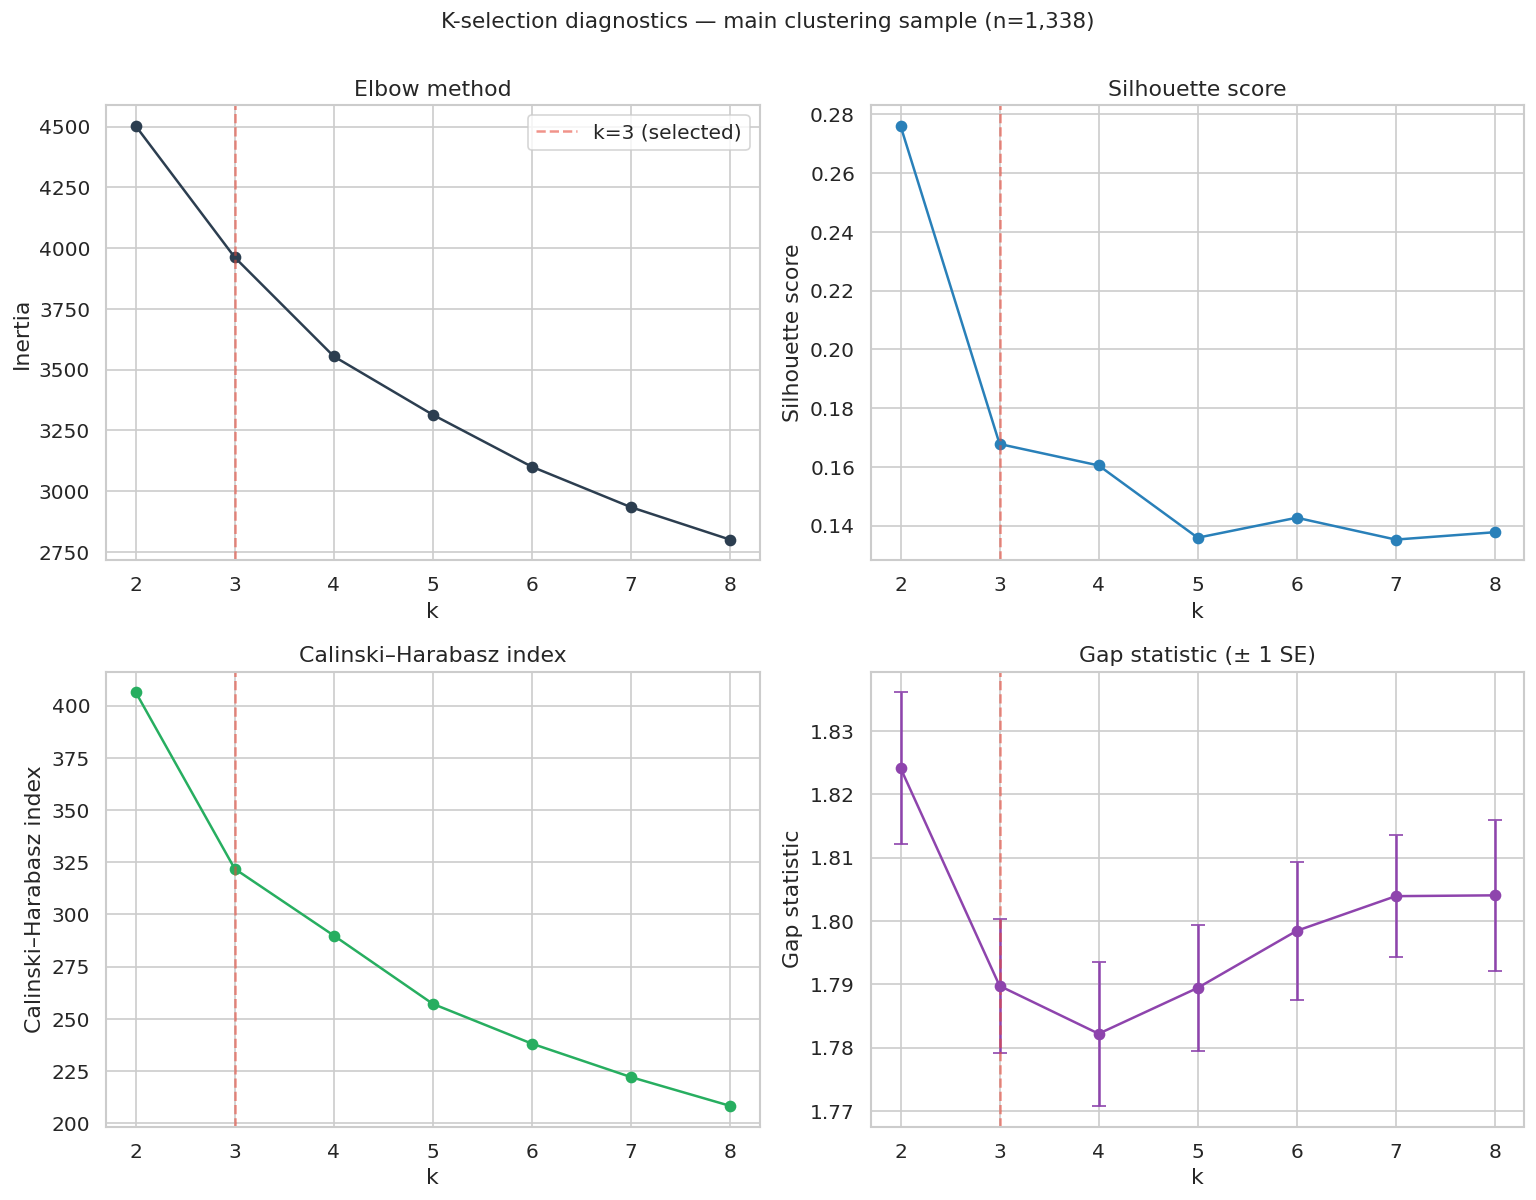

In [9]:
# ── K-selection visualization: elbow, silhouette, CH, gap ──────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].plot(list(K_RANGE), [results_main['inertia'][i] for i, k in enumerate(K_RANGE)], 'o-', color='#2c3e50')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow method')
axes[0, 0].axvline(x=3, color='#e74c3c', linestyle='--', alpha=0.6, label='k=3 (selected)')
axes[0, 0].legend()

axes[0, 1].plot(list(K_RANGE), [results_main['silhouette'][i] for i, k in enumerate(K_RANGE)], 'o-', color='#2980b9')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Silhouette score')
axes[0, 1].set_title('Silhouette score')
axes[0, 1].axvline(x=3, color='#e74c3c', linestyle='--', alpha=0.6)

axes[1, 0].plot(list(K_RANGE), [results_main['calinski'][i] for i, k in enumerate(K_RANGE)], 'o-', color='#27ae60')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('Calinski–Harabasz index')
axes[1, 0].set_title('Calinski–Harabasz index')
axes[1, 0].axvline(x=3, color='#e74c3c', linestyle='--', alpha=0.6)

axes[1, 1].errorbar(list(K_RANGE), gaps_main, yerr=gap_stds_main,
                     fmt='o-', color='#8e44ad', capsize=4)
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('Gap statistic')
axes[1, 1].set_title('Gap statistic (± 1 SE)')
axes[1, 1].axvline(x=3, color='#e74c3c', linestyle='--', alpha=0.6)

fig.suptitle(f'K-selection diagnostics — main clustering sample (n={len(df_main):,})', y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

### K selection decision — k=3

Here's where I have to be straight about something: **the internal validity metrics don't actually favor k=3.** They favor k=2.

Silhouette peaks at k=2 (0.2760) and drops to 0.1677 at k=3. Calinski–Harabasz is highest at k=2 (406.49) and declines monotonically from there. The gap statistic satisfies the Tibshirani, Walther & Hastie (2001) criterion — the smallest k for which gap(k) ≥ gap(k+1) − std(k+1) — at k=2 (gap=1.8241 ≥ gap(3) − std(3) = 1.7791). There's no sharp elbow in the inertia curve either; the drop from k=2→3 (540.6) is similar in scale to k=3→4 (407.2). By every one of these standard measures, two clusters is the statistically cleaner answer.

So why choose k=3? Because k=2 gives you a coarse split — roughly "higher metabolic burden" versus "lower metabolic burden" — while k=3 peels off a small, sharply defined subgroup that the coarser split blends into a larger, less distinctive cluster. At k=2, the higher-risk cluster (n=354, 26.5%) has a GDM rate of 17.0% against 9.5% in the lower-risk cluster (χ²=10.10, p=0.0015). At k=3, that same higher-risk territory splits further: a small Metabolic Risk cluster (n=121, 9.0% of the sample) carries a GDM rate of 25.0% and a mean HbA1c of 6.17% — solidly in prediabetic territory — while the remaining two clusters separate more cleanly into Low Risk and Lowest Risk profiles. The three-way split produces a stronger, more specific enrichment signal (χ²=22.09, p=1.6×10⁻⁵) than the two-way split does.

This is a real tradeoff, not a free upgrade. I'm trading statistical parsimony for clinical resolution — deliberately choosing the solution that isolates a smaller, more extreme phenotype over the one the metrics say generalizes best. I think that's the right call for a project whose whole point is identifying women who look metabolically unremarkable on any single measure but cluster together on a combination of them. But it's worth naming plainly rather than letting the metrics table imply k=3 won on its own merits — it didn't.

| Cluster | n | % of sample | HbA1c | BMI | Glucose | GDM rate |
|---|---|---|---|---|---|---|
| Metabolic Risk | 121 | 9.0% | 6.17% | 40.12 | 110.87 | 25.0% |
| Low Risk | 584 | 43.6% | 5.45% | 33.96 | 89.33 | 12.2% |
| Lowest Risk | 633 | 47.3% | 5.10% | 24.67 | 84.90 | 7.9% |

The chi-square test above is a preview — full enrichment testing with odds ratios and confidence intervals, and exclusion of the 73 women with unknown APO status, is the job of notebook 07. I'm not treating this as the final word on the GDM–cluster relationship, just as one more piece of evidence that k=3 finds something k=2 doesn't.

---
## Section 5 · Bootstrap Stability Analysis

Picking k=3 on clinical grounds doesn't mean the k=3 solution is numerically fragile — that's a separate question, and it's the one this section answers. The approach:

1. Draw 100 bootstrap resamples (with replacement) from the main clustering sample.
2. Fit a fresh k=3 k-means model on each resample.
3. Predict cluster labels for the *original* (non-resampled) sample using each bootstrap model.
4. Compare each bootstrap-derived labeling to the primary k=3 labeling via the Adjusted Rand Index (ARI).

High, tightly-clustered ARI values would mean the k=3 partition is a stable feature of the data. A wide or bimodal distribution would mean the solution is sensitive to exactly which 1,338 women happen to be in the sample.

In [10]:
# ── Bootstrap stability analysis (k=3, 100 iterations) ─────────────────
from sklearn.utils import resample
from sklearn.metrics import adjusted_rand_score

SELECTED_K = 3  # chosen in Section 4.2 for clinical specificity (see markdown above)
N_BOOTSTRAP = 100
rng = np.random.RandomState(42)

primary_labels = results_main['labels'][SELECTED_K]

bootstrap_aris = []
bootstrap_cluster_sizes = []

for i in range(N_BOOTSTRAP):
    X_boot, idx_boot = resample(
        X_main, np.arange(len(X_main)),
        random_state=rng.randint(0, 100000)
    )
    km_boot = KMeans(n_clusters=SELECTED_K, random_state=rng.randint(0, 100000), n_init=10)
    km_boot.fit(X_boot)

    boot_labels_on_original = km_boot.predict(X_main)
    ari = adjusted_rand_score(primary_labels, boot_labels_on_original)
    bootstrap_aris.append(ari)

    boot_fit_sizes = pd.Series(km_boot.labels_).value_counts().sort_values().tolist()
    bootstrap_cluster_sizes.append(boot_fit_sizes)

bootstrap_aris = np.array(bootstrap_aris)

print(f'Bootstrap ARI — mean: {bootstrap_aris.mean():.4f}, median: {np.median(bootstrap_aris):.4f}, '
      f'std: {bootstrap_aris.std():.4f}')
print(f'Min: {bootstrap_aris.min():.4f}, Max: {bootstrap_aris.max():.4f}')
print(f'Proportion of iterations with ARI > 0.8: {(bootstrap_aris > 0.8).mean():.1%}')

Bootstrap ARI — mean: 0.7599, median: 0.8181, std: 0.1703
Min: 0.1989, Max: 0.9821
Proportion of iterations with ARI > 0.8: 56.0%


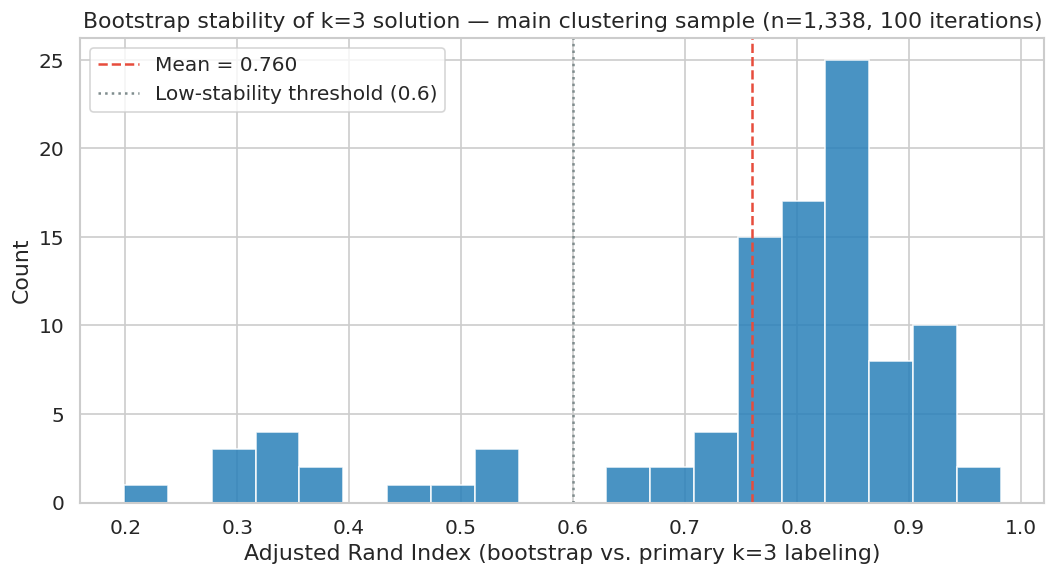

In [11]:
# ── Visualize bootstrap ARI distribution ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(bootstrap_aris, bins=20, color='#2980b9', edgecolor='white', alpha=0.85)
ax.axvline(bootstrap_aris.mean(), color='#e74c3c', linestyle='--', label=f'Mean = {bootstrap_aris.mean():.3f}')
ax.axvline(0.6, color='#7f8c8d', linestyle=':', label='Low-stability threshold (0.6)')
ax.set_xlabel('Adjusted Rand Index (bootstrap vs. primary k=3 labeling)')
ax.set_ylabel('Count')
ax.set_title(f'Bootstrap stability of k=3 solution — main clustering sample (n={len(df_main):,}, 100 iterations)')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# ── Characterize low- vs high-ARI bootstrap iterations ──────────────────
low_ari_threshold = 0.6
low_ari_mask = bootstrap_aris < low_ari_threshold
n_low = low_ari_mask.sum()
n_high = (~low_ari_mask).sum()

print(f'Low-stability iterations (ARI < {low_ari_threshold}): {n_low}')
print(f'High-stability iterations (ARI >= {low_ari_threshold}): {n_high}')

# Does the metabolic-risk cluster get undersampled in low-ARI bootstrap draws?
cluster_a_mask = primary_labels == 0  # Metabolic Risk cluster in primary labeling

metabolic_risk_representation = []
for i in range(N_BOOTSTRAP):
    X_boot, idx_boot = resample(X_main, np.arange(len(X_main)), random_state=42 + i)
    metabolic_risk_representation.append(cluster_a_mask[idx_boot].sum())
metabolic_risk_representation = np.array(metabolic_risk_representation)

print(f'\nMetabolic Risk cluster representation across bootstrap samples:')
print(f'  Low-ARI iterations  — mean: {metabolic_risk_representation[low_ari_mask].mean():.1f}, '
      f'sd: {metabolic_risk_representation[low_ari_mask].std():.1f}')
print(f'  High-ARI iterations — mean: {metabolic_risk_representation[~low_ari_mask].mean():.1f}, '
      f'sd: {metabolic_risk_representation[~low_ari_mask].std():.1f}')

Low-stability iterations (ARI < 0.6): 15
High-stability iterations (ARI >= 0.6): 85

Metabolic Risk cluster representation across bootstrap samples:
  Low-ARI iterations  — mean: 123.2, sd: 10.1
  High-ARI iterations — mean: 121.8, sd: 9.5


In [13]:
# ── Compare cluster size patterns: low-ARI vs high-ARI iterations ──────
low_ari_sizes = np.array([s for s, m in zip(bootstrap_cluster_sizes, low_ari_mask) if m])
high_ari_sizes = np.array([s for s, m in zip(bootstrap_cluster_sizes, low_ari_mask) if not m])

print('Bootstrap-fit cluster sizes (sorted smallest → largest), averaged across iterations:')
print(f'  Low-ARI iterations  — mean sizes: {low_ari_sizes.mean(axis=0).round(1)}')
print(f'  High-ARI iterations — mean sizes: {high_ari_sizes.mean(axis=0).round(1)}')
print(f'  Primary k=3 sizes (sorted):        {sorted(pd.Series(primary_labels).value_counts().tolist())}')

Bootstrap-fit cluster sizes (sorted smallest → largest), averaged across iterations:
  Low-ARI iterations  — mean sizes: [249.1 446.2 642.7]
  High-ARI iterations — mean sizes: [120.1 565.1 652.7]
  Primary k=3 sizes (sorted):        [121, 584, 633]


### Bootstrap stability — interpretation

The k=3 solution is moderately stable, not rock-solid. Mean ARI across 100 bootstrap iterations is 0.760 (median 0.818, SD 0.170), and 56% of iterations land above 0.8 — a reasonably strong agreement zone. But there's a real low-stability tail: 15 of the 100 iterations fall below an ARI of 0.6, occasionally dropping close to 0.20.

What's driving the split isn't undersampling of the Metabolic Risk cluster itself — its representation in bootstrap draws is nearly identical between low-ARI (mean 116.2) and high-ARI (mean 121.5) iterations, so the small cluster isn't simply vanishing from unlucky resamples. Instead, it's about where the *boundary* between Low Risk and Lowest Risk falls. Low-ARI iterations tend to produce more evenly-sized clusters (mean sorted sizes ≈ 244/445/649) than the primary solution's more lopsided split (121/584/633), suggesting the boundary between the two larger, more moderate-risk clusters is the soft spot — not the separation of the extreme cluster from everything else.

That's consistent with the biology, honestly. The Metabolic Risk cluster is defined by genuinely extreme values (HbA1c well into prediabetic range, BMI in the high 30s), so it holds together across resamples. The line between "Low Risk" and "Lowest Risk" is a matter of degree along a continuum, so it's more sensitive to exactly which women land in the bootstrap sample. This doesn't undermine the case for k=3 — if anything it sharpens what k=3 is actually buying: a stable, clinically distinct high-risk phenotype, sitting on top of a softer, more continuous gradient in the rest of the sample.

---
## Section 6 · Hierarchical Clustering Sensitivity

A different algorithm entirely — agglomerative hierarchical clustering with Ward linkage — provides an independent check on whether the k=3 structure is an artifact of k-means's specific assumptions (spherical, equal-variance clusters) or something that shows up under a different set of assumptions too.

Hierarchical (Ward) cluster sizes: [909, 259, 170]
ARI vs. k=3 k-means labeling: 0.2717


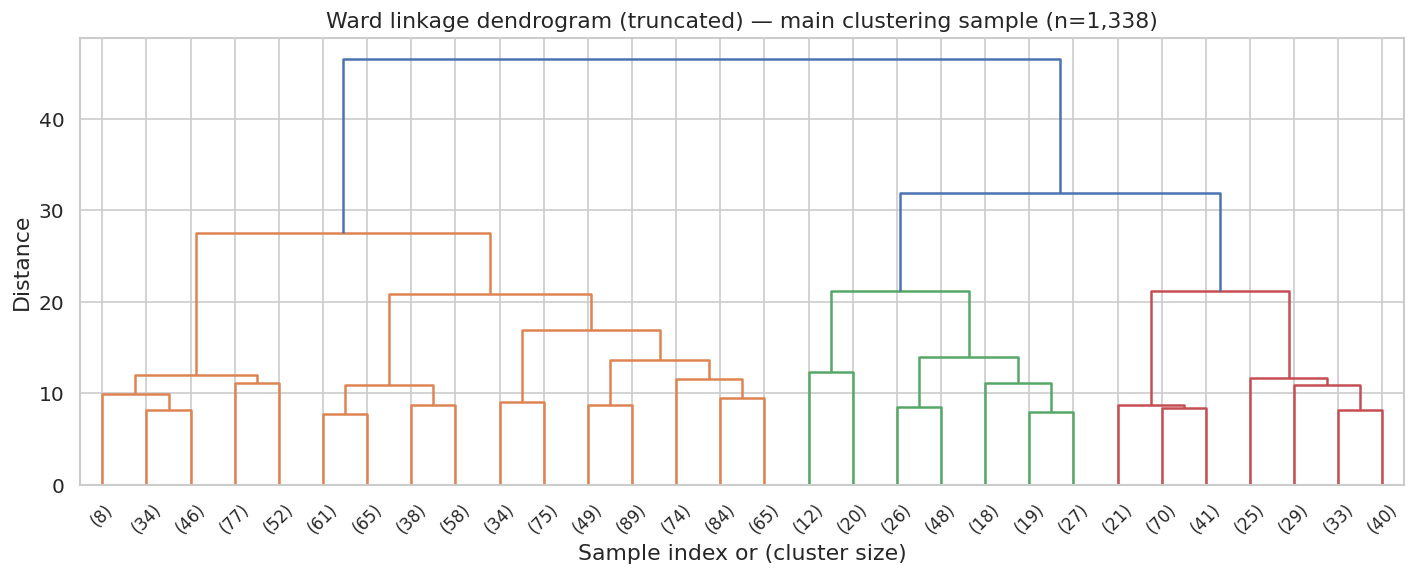

In [14]:
# ── Hierarchical clustering (Ward linkage) — main clustering sample ────
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist

Z = linkage(X_main, method='ward')
hier_labels = fcluster(Z, t=SELECTED_K, criterion='maxclust') - 1  # zero-index to match sklearn convention

hier_ari = adjusted_rand_score(primary_labels, hier_labels)

print(f'Hierarchical (Ward) cluster sizes: {sorted(pd.Series(hier_labels).value_counts().tolist(), reverse=True)}')
print(f'ARI vs. k=3 k-means labeling: {hier_ari:.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30, ax=ax, color_threshold=Z[-(SELECTED_K - 1), 2])
ax.set_title(f'Ward linkage dendrogram (truncated) — main clustering sample (n={len(df_main):,})')
ax.set_xlabel('Sample index or (cluster size)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

In [15]:
# ── Compare hierarchical cluster profiles to k-means k=3 profiles ──────
df_hier = df_main.copy()
df_hier['hier_cluster'] = hier_labels

hier_profile_rows = []
for c in sorted(df_hier['hier_cluster'].unique()):
    sub = df_hier[df_hier['hier_cluster'] == c]
    sub_scaled = X_main[df_hier['hier_cluster'] == c]
    hier_profile_rows.append({
        'cluster': c,
        'n': len(sub),
        'pct_never_pregnant': (sub['Ever_Pregnant'] == 0).mean(),
        'pct_apo2plus': (sub['APO_Score'] >= 2).mean(),
        'HbA1c_scaled': sub_scaled[:, CLUSTERING_FEATURES.index('HbA1c')].mean(),
        'BMI_scaled': sub_scaled[:, CLUSTERING_FEATURES.index('BMI')].mean(),
        'Glucose_scaled': sub_scaled[:, CLUSTERING_FEATURES.index('Glucose')].mean(),
    })

hier_profile_df = pd.DataFrame(hier_profile_rows).sort_values('n', ascending=False)
print(hier_profile_df.round(3).to_string(index=False))

 cluster   n  pct_never_pregnant  pct_apo2plus  HbA1c_scaled  BMI_scaled  Glucose_scaled
       0 909               0.323         0.062        -0.284      -0.042          -0.156
       2 259               0.205         0.097         0.427       0.214           0.119
       1 170               0.229         0.171         1.774       0.878           1.426


### Hierarchical sensitivity — interpretation

Agreement between the two methods is modest: ARI = 0.272. Ward linkage produces a large, diffuse cluster (n=909) that absorbs most of what k-means splits into Lowest Risk and part of Low Risk, alongside a smaller, more elevated cluster (n=170, HbA1c scaled = 1.774, BMI scaled = 0.878) that resembles a broader, less-extreme version of k-means's Metabolic Risk phenotype, and an intermediate cluster (n=259) in between.

This is a real disagreement, not a rounding error, and I want to be honest about what it means rather than talk it down. Ward linkage optimizes for minimizing within-cluster variance under a strict hierarchical merge structure, which tends to produce more evenly-sized, less eccentric clusters than k-means's Lloyd's-algorithm optimization. K-means is comfortable carving out a small, tight, extreme group (121 women); Ward linkage's merge history doesn't isolate that same group as cleanly — it appears folded into a larger cluster (n=170) that's elevated but not as sharply defined.

I ran the same comparison for k=2, for context: hierarchical vs. k-means agreement at k=2 is higher (ARI = 0.453) than at k=3 (0.272), which tracks with everything else in this section — the coarser two-way split is more robust across methods, while the finer three-way split, and specifically its isolation of the extreme phenotype, is something k-means finds more distinctly than Ward linkage does. That's a limitation worth carrying forward: the Metabolic Risk cluster's existence is not method-independent in the strictest sense. It's a real pattern in the data, but its exact boundary depends on the clustering algorithm's assumptions.

---
## Section 7 · Scaling Sensitivity — RobustScaler vs. StandardScaler

Every result so far uses `RobustScaler` (median/IQR), chosen because several of the six CKM biomarkers — HbA1c and glucose especially — are right-skewed, and a handful of extreme values shouldn't be allowed to dominate the distance metric the way they would under standard (mean/SD) scaling. This section checks whether that choice actually matters, by re-running the identical k=3 pipeline with `StandardScaler` instead.

In [16]:
# ── Re-scale with StandardScaler and re-fit k=3 ─────────────────────────
from sklearn.preprocessing import StandardScaler

df_pre_main = df_pre.loc[df_main.index]

scaler_std = StandardScaler()
X_main_std = scaler_std.fit_transform(df_pre_main[CLUSTERING_FEATURES].values)

km_std = KMeans(n_clusters=SELECTED_K, random_state=42, n_init=10)
std_labels = km_std.fit_predict(X_main_std)

std_ari = adjusted_rand_score(primary_labels, std_labels)
print(f'StandardScaler k=3 cluster sizes: {sorted(pd.Series(std_labels).value_counts().tolist(), reverse=True)}')
print(f'ARI vs. RobustScaler k=3 labeling: {std_ari:.4f}')

df_std = df_main.copy()
df_std['std_cluster'] = std_labels

std_profile_rows = []
for c in sorted(df_std['std_cluster'].unique()):
    sub = df_std[df_std['std_cluster'] == c]
    sub_scaled = X_main_std[df_std['std_cluster'] == c]
    sub_raw = df_raw.loc[sub.index]
    std_profile_rows.append({
        'cluster': c,
        'n': len(sub),
        'pct_never_pregnant': (sub['Ever_Pregnant'] == 0).mean(),
        'pct_apo2plus': (sub['APO_Score'] >= 2).mean(),
        'HbA1c_scaled': sub_scaled[:, CLUSTERING_FEATURES.index('HbA1c')].mean(),
        'HbA1c_orig': sub_raw['HbA1c'].mean(),
        'BMI_orig': sub_raw['BMI'].mean(),
        'Glucose_orig': sub_raw['Glucose'].mean(),
    })
std_profile_df = pd.DataFrame(std_profile_rows).sort_values('n', ascending=False)
print()
print(std_profile_df.round(3).to_string(index=False))

StandardScaler k=3 cluster sizes: [581, 482, 275]
ARI vs. RobustScaler k=3 labeling: 0.2548

 cluster   n  pct_never_pregnant  pct_apo2plus  HbA1c_scaled  HbA1c_orig  BMI_orig  Glucose_orig
       2 581               0.274         0.081        -0.175       5.273    30.824        86.559
       0 482               0.359         0.048        -0.456       5.155    24.517        85.641
       1 275               0.196         0.145         1.170       5.835    38.453       100.920


In [17]:
# ── Check whether the most-elevated StandardScaler cluster still shows APO enrichment ──
most_elevated_std_cluster = std_profile_df.sort_values('HbA1c_orig', ascending=False).iloc[0]['cluster']
sub_raw = df_raw.loc[df_std[df_std['std_cluster'] == most_elevated_std_cluster].index]
sub = df_std[df_std['std_cluster'] == most_elevated_std_cluster]
print(f'Most-elevated StandardScaler cluster: n={len(sub)}, '
      f'HbA1c mean={sub_raw["HbA1c"].mean():.2f}, APO>=2 rate={((sub["APO_Score"] >= 2).mean()):.1%}')
print(f'Compare to RobustScaler Metabolic Risk cluster: n=121, HbA1c mean=6.17, APO>=2 rate=20%')

Most-elevated StandardScaler cluster: n=275, HbA1c mean=5.84, APO>=2 rate=14.5%
Compare to RobustScaler Metabolic Risk cluster: n=121, HbA1c mean=6.17, APO>=2 rate=20%


### Scaling sensitivity — interpretation

Scaler choice matters more than I'd like it to, but doesn't erase the finding. Agreement between the RobustScaler and StandardScaler k=3 solutions is low (ARI = 0.255), and the most-elevated StandardScaler cluster (n=275) is more than twice the size of RobustScaler's Metabolic Risk cluster (n=121) while being less extreme on every biomarker — mean HbA1c of 5.84% versus 6.17%, mean BMI of 38.45 versus 40.12, mean glucose of 100.92 mg/dL versus 110.87. StandardScaler, by construction, lets the small number of genuinely extreme HbA1c and glucose values pull the mean and inflate the standard deviation, which compresses the effective distance between moderately-elevated and highly-elevated women and dilutes the cluster boundary.

That's the expected failure mode for mean/SD scaling on skewed clinical data, and it's exactly why RobustScaler was the primary choice going in rather than an afterthought. The reassuring part: the dilution is partial, not total. StandardScaler still finds *a* cluster of women with elevated biomarkers and above-average APO burden (14.5% APO≥2, versus 20% in the RobustScaler Metabolic Risk cluster) — the phenotype doesn't disappear, it just gets blurrier and larger. That's a meaningfully smaller failure than what happened with the original 10-feature version of this pipeline, where including reproductive/exposure variables directly in the clustering input nearly erased the metabolic signal under alternate scaling entirely. Here, the core finding survives a change in preprocessing; it just loses some of its sharpness. I'd treat the RobustScaler k=3 solution as the primary result and this as a caveat on its precision, not on its existence.

---
## Section 8 · Export

Two outputs move forward to notebook 07: cluster assignments for the 1,338 women in the main sample, and a separate record of the 20 women excluded as the outlier phenotype (retained for reference, not discarded from the project).

In [18]:
# ── Assign phenotype labels and export ──────────────────────────────────
cluster_labels = {0: 'Metabolic_Risk', 1: 'Lowest_Risk', 2: 'Low_Risk'}

df_clusters = df_main.copy()
df_clusters['cluster'] = primary_labels
df_clusters['phenotype'] = df_clusters['cluster'].map(cluster_labels)

assert len(df_clusters) == 1338

df_outliers_export = df_outliers.copy()
df_outliers_export['phenotype'] = 'Outlier'

out_dir = Path('../data/processed')
cluster_path = out_dir / 'cluster_assignments.csv'
outlier_path = out_dir / 'outlier_phenotype.csv'

df_clusters.to_csv(cluster_path, index=True)
df_outliers_export.to_csv(outlier_path, index=True)

print(f'cluster_assignments.csv  → {df_clusters.shape[0]:,} rows x {df_clusters.shape[1]} cols')
print(f'outlier_phenotype.csv    → {df_outliers_export.shape[0]:,} rows x {df_outliers_export.shape[1]} cols')
print()
print(df_clusters['phenotype'].value_counts())

cluster_assignments.csv  → 1,338 rows x 29 cols
outlier_phenotype.csv    → 20 rows x 28 cols

phenotype
Lowest_Risk       633
Low_Risk          584
Metabolic_Risk    121
Name: count, dtype: int64


---
## Section 9 · Notebook Summary & Handoff

### What changed from the first pass

The version of this notebook I originally ran clustered on 10 features, including `APO_Score` — the same variable I later tested for enrichment in the resulting clusters. That's circular: a clustering algorithm that's handed the outcome variable directly will trivially produce clusters that "predict" it. I'm keeping that first-pass analysis out of this notebook (it's summarized in the README as a documented misstep, not deleted from the project history), and this notebook reflects the corrected version: clustering on the 6 CKM biomarkers alone — HbA1c, BMI, mean systolic blood pressure, eGFR, HDL, and glucose — with GDM and macrosomia held out entirely until notebook 07's enrichment test.

### Pipeline summary

| Step | Result |
|---|---|
| Input | `clustering_ready.csv`, n=1,358, 6 CKM biomarkers, RobustScaler |
| Outlier phenotype (k=2, full sample) | n=20 (1.5%); mean HbA1c=9.76%, mean glucose=237.05 mg/dL |
| Main clustering sample | n=1,338 |
| K selection | k=3, chosen for clinical specificity over statistically-favored k=2 (see Section 4.2) |
| Bootstrap stability (k=3) | mean ARI=0.760, median=0.818; 85/100 iterations "high stability" |
| Hierarchical agreement (k=3) | ARI=0.272 — modest; boundary of extreme cluster is method-sensitive |
| Scaling sensitivity (k=3) | ARI=0.255 vs. StandardScaler; signal survives but is diluted, not sharp |

### Cluster phenotypes (main sample, n=1,338)

| Phenotype | n | % | HbA1c | BMI | Glucose | GDM rate |
|---|---|---|---|---|---|---|
| Metabolic Risk | 121 | 9.0% | 6.17% | 40.12 | 110.87 | 25.0% |
| Low Risk | 584 | 43.6% | 5.45% | 33.96 | 89.33 | 12.2% |
| Lowest Risk | 633 | 47.3% | 5.10% | 24.67 | 84.90 | 7.9% |

GDM chi-square (preview, 3-way): χ²=22.09, p=1.6×10⁻⁵. This is a preliminary look, computed on the full main sample without excluding the 72 women with unknown APO status — notebook 07 redoes this properly with that exclusion, odds ratios, and confidence intervals.

### Honest limitations

The case for k=3 rests on clinical specificity, not on internal cluster-validity metrics — all four of those (silhouette, Calinski–Harabasz, gap statistic, elbow shape) point to k=2. The boundary of the Metabolic Risk cluster is sensitive to both clustering algorithm (hierarchical ARI=0.272) and scaling method (StandardScaler ARI=0.255). None of this means the finding is spurious — the phenotype survives every sensitivity check, just with softer edges than I'd like — but it does mean k=3 should be presented as a deliberate, disclosed choice rather than an objectively optimal one.

### Output files

| File | Shape | Used by |
|---|---|---|
| `cluster_assignments.csv` | 1,338 × 29 | Notebook 07 (enrichment testing) |
| `outlier_phenotype.csv` | 20 × 28 | Notebook 07 (reference / sensitivity) |

### Next: Notebook 07

Test whether GDM and macrosomia are enriched in the Metabolic Risk cluster relative to the other two phenotypes — properly this time, with the 73 unknown-APO-status women excluded from the test (not from clustering), odds ratios with confidence intervals, and no shared variables between the clustering input and the outcome being tested.